## PARIS inverse modelling results

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `model_filenames` dictionary to point towards the experiment/model you want to plot. Update the `model_labels` and `model_colors` dictionaries, these change how each model is labelled in the plots.

3. Run the cell below, before running any of the plotting code.

In [ ]:
p = xr.open_dataset('/home/h02/aramsden/project_InTEM_GHG_inversion/priors/raw_priors/CH4_PLevy_Mar2022/')

In [49]:
o = xr.open_dataset('/home/h02/aramsden/results/multi_gas_MCMC/MCMC_output/real_data/ch4_c2h6/real-varR_ch4_c2h6_20230801-150basis_7sites_EUROPE_full_run_post.nc')

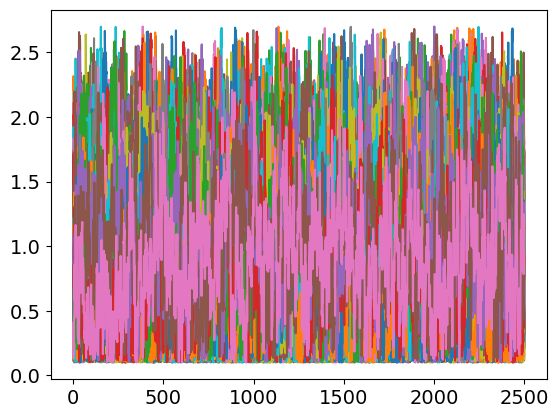

In [51]:
plt.plot(o['R_post_c2h6_FF']);

In [12]:

%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

#data_dir = '/project/InTEM_GHG/inversion/PARIS_results_sharing/'
data_dir = '/home/h02/aramsden/results/multi_gas_MCMC/processed_output/'

model_filenames = {'rhime':'RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_33sites*',
                  'rhime_edgar_allobs':'RHIME_NAME_EUROPE_EDGAR_all_obs*',
                  'intem':'InTEM_NAME_EUROPE_5UK_site_test*',
                  'intem_14sites':'InTEM_NAME_EUROPE_EDGAR_14sites_new_obs',
                  'mcmc':'MCMC_NAME_EUROPE',
                    'mcmc_gaussian_2uncert':'MCMC_NAME_EUROPE_gaussian_2uncert',
                  'mcmc_075flux':'MCMC_NAME_EUROPE_075flux',
                  'mcmc_forward':'MCMC_NAME_EUROPE_forward_model',
                  'mcmc_c2h6_forward':'MCMC_NAME_EUROPE_c2h6_varR_forward_model',
                  'mcmc_c2h6':'MCMC_NAME_EUROPE_c2h6_varR',
                  'mcmc_c2h6_fixedR':'MCMC_NAME_EUROPE_c2h6_gaussian_2uncert_fixedR',
                  'mcmc_c2h6_gaussian_2uncert':'MCMC_NAME_EUROPE_c2h6_gaussian_2uncert_varR',
                  'mcmc_c2h6_01uncertBC':'MCMC_NAME_EUROPE_c2h6_01uncertBC_varR',
                  'mcmc_c2h6_lowmoderror':'MCMC_NAME_EUROPE_c2h6_lowmoderror_varR',
                  'mcmc_d13_forward':'MCMC_NAME_EUROPE_dch4c13_varR_forward_model',
                  'mcmc_c2h6_d13_forward':'MCMC_NAME_EUROPE_c2h6_dch4c13_varR_forward_model',
                  'mcmc_c2h6_d13':'MCMC_NAME_EUROPE_c2h6_dch4c13_varR',
                  'mcmc_d13_dD_forward':'MCMC_NAME_EUROPE_dch4c13_dch4d_varR_forward_model',
                  'mcmc_d13_dD':'MCMC_NAME_EUROPE_dch4c13_dch4d_varR',
                  'mcmc_d13_dD_gaussian_2uncert':'MCMC_NAME_EUROPE_dch4c13_dch4d_gaussian_2uncert_varR',
                  'mcmc_d13_dD_new_Rbc':'MCMC_NAME_EUROPE_dch4c13_dch4d_varR_new_Rbc',
                  'mcmc_c2h6_d13_dD_forward':'MCMC_NAME_EUROPE_c2h6_dch4c13_dch4d_varR_forward_model',
                  'mcmc_c2h6_d13_dD':'MCMC_NAME_EUROPE_c2h6_dch4c13_dch4d_varR',
                  'mcmc_c2h6_d13_dD_fixedR':'MCMC_NAME_EUROPE_c2h6_dch4c13_dch4d_gaussian_2uncert_fixedR',
                  'mcmc_c2h6_d13_dD_gaussian_2uncert':'MCMC_NAME_EUROPE_c2h6_dch4c13_dch4d_gaussian_2uncert_varR',
                  'mcmc_c2h6_d13_dD_2uncert':'MCMC_NAME_EUROPE_c2h6_dch4c13_dch4d_2uncert_varR',
                  'intem_7sites':'InTEM_NAME_EUROPE_EDGAR_7sites'}

model_labels = {'rhime':'RHIME 33 sites',
                  'rhime_edgar_allobs':'RHIME all obs',
                  'intem':'InTEM 5 sites',
                  'intem_14sites':'InTEM 14 sites',
                  'mcmc_forward':'MCMC CH$_4$',
                  'mcmc':'MCMC CH$_4$',
                  'mcmc_gaussian_2uncert':'MCMC CH$_4$',# Gaussian 200% uncert',
                  'mcmc_075flux':'MCMC CH$_4$ 0.75 flux',
                  'mcmc_c2h6_forward':'MCMC CH$_4$+C$_2$H$_6$',
                  'mcmc_c2h6':'MCMC CH$_4$+C$_2$H$_6$',
                  'mcmc_c2h6_fixedR':'MCMC CH$_4$+C$_2$H$_6$ fixedR',
                  'mcmc_c2h6_gaussian_2uncert':'MCMC CH$_4$+C$_2$H$_6$',# Gaussian 200% uncert',
                  'mcmc_c2h6_01uncertBC':'MCMC CH$_4$+C$_2$H$_6$ 10% BC uncert',
                  'mcmc_c2h6_lowmoderror':'MCMC CH$_4$+C$_2$H$_6$ low mod error',
                  'mcmc_d13_forward':'MCMC CH$_4$+$\delta^{13}$C-CH$_4$',
                  'mcmc_c2h6_d13_forward':'MCMC CH$_4$+C$_2$H$_6$+ $\delta^{13}$C-CH$_4$',
                  'mcmc_c2h6_d13':'MCMC CH$_4$+C$_2$H$_6$+ $\delta^{13}$C-CH$_4$',
                  'mcmc_d13_dD_forward':'MCMC CH$_4$+$\delta^{13}$C-CH$_4$+$\delta^{2}$H-CH$_4$',
                  'mcmc_d13_dD':'MCMC CH$_4$+$\delta^{13}$C-CH$_4$+$\delta^{2}$H-CH$_4$',
                  'mcmc_d13_dD_gaussian_2uncert':'MCMC CH$_4$+$\delta^{13}$C-CH$_4$+$\delta^{2}$H-CH$_4$',# Gaussian 200% uncert',
                  'mcmc_d13_dD_new_Rbc':'MCMC CH$_4$+$\delta^{13}$C-CH$_4$+$\delta^{2}$H-CH$_4$ new Rbc',
                  'mcmc_c2h6_d13_dD_forward':'MCMC CH$_4$+C$_2$H$_6$+$\delta^{13}$C-CH$_4$+$\delta^{2}$H-CH$_4$',
                  'mcmc_c2h6_d13_dD':'MCMC CH$_4$+C$_2$H$_6$+$\delta^{13}$C-CH$_4$+$\delta^{2}$H-CH$_4$',
                  'mcmc_c2h6_d13_dD_fixedR':'MCMC CH$_4$+C$_2$H$_6$+$\delta^{13}$C-CH$_4$+$\delta^{2}$H-CH$_4$ fixedR',
                  'mcmc_c2h6_d13_dD_gaussian_2uncert':'MCMC CH$_4$+C$_2$H$_6$+$\delta^{13}$C-CH$_4$+$\delta^{2}$H-CH$_4$',# Gaussian 200 %uncert',
                  'mcmc_c2h6_d13_dD_2uncert':'MCMC CH$_4$+C$_2$H$_6$+$\delta^{13}$C-CH$_4$+$\delta^{2}$H-CH$_4$ 200% uncert',
                  'intem_7sites':'InTEM 7 sites'}

model_colors = {'rhime':['dimgrey','grey'],
                'rhime_edgar_allobs':['orange','gold'],
                'intem':['dimgrey','grey'],
                'intem_14sites':['orange','goldenrod'],
                  'mcmc_forward':['darkblue','dodgerblue'],
                  'mcmc':['darkblue','dodgerblue'],
                  'mcmc_gaussian_2uncert':['darkblue','dodgerblue'],
                  'mcmc_075flux':['darkorange','darkorange'],
                  'mcmc_c2h6_forward':['firebrick','indianred'],
                  'mcmc_c2h6':['firebrick','indianred'],
                  'mcmc_c2h6_fixedR':['pink','indianred'],
                  'mcmc_c2h6_gaussian_2uncert':['firebrick','indianred'],
                  'mcmc_c2h6_lowmoderror':['purple','mediumpurple'],
                  'mcmc_c2h6_01uncertBC':['firebrick','pink'],
                  'mcmc_d13_forward':['firebrick','pink'],
                  'mcmc_c2h6_d13_forward':['turquoise','teal'],
                  'mcmc_c2h6_d13':['turquoise','teal'],
                  'mcmc_d13_dD_forward':['darkgreen','teal'],
                  'mcmc_d13_dD':['teal','dodgerblue'],#['darkgreen','teal'],
                  'mcmc_d13_dD_gaussian_2uncert':['teal','dodgerblue'],#['darkgreen','teal'],
                  'mcmc_d13_dD_new_Rbc':['orange','goldenrod'],
                  'mcmc_c2h6_d13_dD_forward':['purple','mediumpurple'],
                  'mcmc_c2h6_d13_dD_gaussian_2uncert':['purple','mediumpurple'],
                  'mcmc_c2h6_d13_dD_fixedR':['purple','mediumpurple'],
                  'mcmc_c2h6_d13_dD':['purple','mediumpurple'],
                  'intem_7sites':['darkorange','grey']}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to choose inputs:

In [ ]:
###################################
### edit variables in this block
species = 'ch4' #'hfc125'
plot_regions = ['SE-ENGLAND','UK','IRELAND','FRANCE','BELGIUM'] #works best with 6 countries but can run with any number (will always create at least 4 subplots though)
#model = ['mcmc','mcmc_2gas','mcmc_filtering','mcmc_new_model_error','mcmc_fixedbc','mcmc_fixed_outer',
#         'mcmc_old_setup','mcmc_2gas_old_setup','intem']
#models = ['mcmc','mcmc_filtering','mcmc_new_model_error','mcmc_fixedbc','mcmc_fixed_outer',
#         'mcmc_old_setup','intem']
models = ['mcmc_gaussian_2uncert','mcmc_c2h6_gaussian_2uncert','mcmc_c2h6_fixedR','mcmc_c2h6_d13_dD_gaussian_2uncert','mcmc_c2h6_d13_dD_fixedR']
#models = ['intem_7sites','mcmc','mcmc_c2h6','mcmc_d13_dD','mcmc_c2h6_d13_dD']
#models = ['mcmc_c2h6_d13_dD','mcmc_c2h6']
#models = ['intem_7sites','mcmc','mcmc_075flux','mcmc_c2h6']#,'mcmc_d13_dD','mcmc_c2h6_d13_dD']
#models = ['mcmc_d13_varR','mcmc_d13_varR_flatbyregion','mcmc_d13_varR_flatbyregion_lowmoderror']
#models = ['mcmc_noicos','mcmc_d13_varR_noicos','mcmc_d13_dD_varR_noicos']

period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2022-01-01' #inclusive
end_date = '2023-11-01' #not inclusive
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                species=species)[m]

#### Timeseries of country fluxes:

In [ ]:
###################################
### edit variables in this block
plot_regions = ['UK','SE-ENGLAND'] #works best with 6 countries but can run with any number (will always create at least 4 subplots though)
plot_inventory = True
inventory_years = ['2023'] #If None, plots most recent. Or can choose list of years: ['2022','2023']
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles
plot_separate = True #If True, includes all model results as separate lines
plot_combined = False #If True, combined results, averaged from all models
plot_separate_by_year = False #If True, plot average flux over each year
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

fig = func.plot_country_flux(ds_all_flux_scaled,species,plot_regions,model_labels,
                             model_colors,
                             plot_inventory,inventory_years,data_dir,fix_y_axes,
                             add_prior_unc,set_global_leg,country_codes_as_titles=country_codes_as_titles,
                             plot_separate=plot_separate,plot_combined=plot_combined,
                             plot_separate_by_year=plot_separate_by_year,period_override=period_override)

Save plot here:

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/real_data_results/country_flux_all_models_truncnormal_1uncert.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries of country fluxes by sector:

In [ ]:
###################################
### edit variables in this block
plot_region = 'SE-ENGLAND' #only 1 region
sectors = ['FF','nonFF']
plot_inventory = True
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles
plot_separate = True #If True, includes all model results as separate lines
plot_combined = False #If True, combined results, averagefrom all models
plot_separate_by_year = False #If True, plot average flux over each year
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

fig = func.plot_country_flux_sectors(ds_all_flux_scaled,species,sectors,plot_region,model_labels,
                             model_colors,
                             plot_inventory,inventory_years,data_dir,fix_y_axes,
                             add_prior_unc,set_global_leg,country_codes_as_titles=country_codes_as_titles,
                             plot_separate=plot_separate,plot_combined=plot_combined,
                             plot_separate_by_year=plot_separate_by_year,period_override=period_override)

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/real_data_results/country_flux_by_sector_SE-ENGLAND_all_models_comparison_gaussian_2uncert.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

In [ ]:
###################################
### edit variables in this block
plot_region = 'SE-ENGLAND' #only 1 region
sectors = ['FF','nonFF','total']
plot_inventory = True
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles
plot_separate = True #If True, includes all model results as separate lines
plot_combined = False #If True, combined results, averagefrom all models
plot_separate_by_year = False #If True, plot average flux over each year
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

fig = func.plot_country_flux_sectors_bar(ds_all_flux_scaled,species,sectors,plot_region,model_labels,
                             model_colors,
                             plot_inventory,inventory_years,data_dir,fix_y_axes,
                             add_prior_unc,set_global_leg,country_codes_as_titles=country_codes_as_titles,
                             plot_separate=plot_separate,plot_combined=plot_combined,
                             plot_separate_by_year=plot_separate_by_year,period_override=period_override)

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/real_data_results/country_flux_by_sector_SE-ENGLAND_bar_all_models.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Plot correlation between total sensitivity and posterior flux

In [ ]:
# these values extracted from c2h6 fp for MHD and TAC, with InTEM obs filtering
# generic_plots.plot_fp_merged_row outputs these values 
totals = np.array([0.002404696840384821,np.nan,0.002384866243121673,0.0031444113566823475,0.0027634784991736093,0.005283922057356855,
          0.00526325055726851,0.005089405929945276,0.0044106977144945094,0.003848234626129688,np.nan,0.0022630494092195194,
          0.0028115558954858234,0.001084259446079494,0.0016806413062308131,0.00019393916027529817,0.0008125566209403434,
          0.0035028033346400965,0.006576852213876633,0.005923005032083821,0.0033123082957665123,0.00235058014481931])
n_obs = np.array([173,np.nan,161,187,125,222,215,209,192,202,np.nan,169,181,81,122,12,41,169,264,218,175,135])
ym = ['2022-01-01','2022-02-01','2022-03-01','2022-04-01','2022-05-01','2022-06-01','2022-07-01',
      '2022-08-01','2022-09-01','2022-10-01','2022-11-01','2022-12-01',
      '2023-01-01','2023-02-01','2023-03-01','2023-04-01','2023-05-01','2023-06-01','2023-07-01',
      '2023-08-01','2023-09-01','2023-10-01']
c_index = np.where(ds_all_flux_scaled['mcmc_c2h6_d13_dD']['countrynumber'].values == 'GBR')[0][0]
ff_flux = ds_all_flux_scaled['mcmc_c2h6_d13_dD']['country_flux_FF_posterior'][:,c_index].values

totals_finite = np.isfinite(totals)
totals_no_nans = totals[totals_finite]
ff_flux_no_nans = ff_flux[totals_finite]
n_obs_no_nans = n_obs[totals_finite]

ff_flux_finite = np.isfinite(ff_flux_no_nans)
totals_no_nans = totals_no_nans[ff_flux_finite]
ff_flux_no_nans = ff_flux_no_nans[ff_flux_finite]
n_obs_no_nans = n_obs_no_nans[ff_flux_finite]

n_obs_finite = np.isfinite(n_obs_no_nans)
totals_no_nans = totals_no_nans[n_obs_finite]
ff_flux_no_nans = ff_flux_no_nans[n_obs_finite]
n_obs_no_nans = n_obs_no_nans[n_obs_finite]

from code.plotting import generic_plots

fig = generic_plots.scatter_plot_with_basic_linear_regression(a=np.expand_dims(ff_flux_no_nans,axis=1),
                                                          b=np.expand_dims(totals_no_nans,axis=1),
                                                          b2=np.expand_dims(n_obs_no_nans,axis=1),
                                                          a_label=f'{model_labels["mcmc_c2h6_d13_dD"]}\nposterior mean FF flux',
                                                          b_label='Total monthly NAME fp sensitivity\nafter obs filtering based on InTEM selection',
                                                          b2_label='Number of C$_2$H$_6$ obs\nafter obs filtering based on InTEM selection')

generic_plots.savefig(fig,'/home/h02/aramsden/results/multi_gas_MCMC/real_data_results/scatter_c2h6_obs_and_fp_vs_FF_flux.png')

#### 1.5 Check for convergence and posterior scaling factor values

In [ ]:
from code.plotting import generic_plots as plot_func

fig = plot_func.plot_all_posterior_scaling_factors(save_name='/home/h02/aramsden/results/multi_gas_MCMC/real_data_results/post_scaling_factors_fixedR_gaussian_2uncert_all_models')

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [17]:
###################################
### edit variables in this block
species = 'ch4'
plot_species = 'dch4c13'
site = 'HFD'
#models = ['mcmc_forward','mcmc_c2h6_forward','mcmc_d13_forward','mcmc_c2h6_d13_forward',
#          'mcmc_d13_dD_forward','mcmc_c2h6_d13_dD_forward']

#models = ['mcmc','mcmc_c2h6','mcmc_d13_dD','mcmc_c2h6_d13_dD','intem_14sites']
#models = ['mcmc_d13_dD_gaussian_2uncert','mcmc_c2h6_d13_dD_gaussian_2uncert']
#models = ['intem_7sites','mcmc_c2h6','mcmc_c2h6_gaussian_2uncert']
models = ['mcmc_c2h6_d13_dD_gaussian_2uncert','mcmc_c2h6_d13_dD_fixedR']

#models = ['mcmc_d13_varR','mcmc_d13_varR_flatbyregion','mcmc_d13_varR_flatbyregion_lowmoderror']
#models = ['intem_14sites','mcmc','mcmc_d13','mcmc_d13_fixedR']
#models = ['intem','mcmc_prop-uncert','mcmc_prop-uncert-high-MHDbc_fixed-outer','mcmc_prop-uncert-high-MHDbc_fixed-outer_filtered']
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2023-04-01' #inclusive
end_date = '2023-11-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs          - total observed mole fraction
# uYobs         - total observed mole fraction uncertainty
# uYmod         - total model mole fraction uncertainty
# Yapriori      - prior total mole fraction
# Yapost        - posterior total mole fraction
# YaprioriBC    - prior baseline
# YapostBC      - posterior baseline
# Ybias         - posterior bias added to site
# YaprioriOuter - prior mole fractions only from outer regions
# YapostOuter   - posterior mole fractions only from outer regions
###################################

ds_all_mf = func.read_mf(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_mf_sliced = {}

for m in models:
    ds_all_mf_sliced[m] = func.slice_mf({m:ds_all_mf[m]},start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,scale_units=True,species=plot_species,
                              remove_missing_timestamps=False)[m]


Attempting to read data from mcmc_c2h6_d13_dD_gaussian_2uncert
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/MCMC/ch4/MCMC_NAME_EUROPE_c2h6_dch4c13_dch4d_gaussian_2uncert_varR_ch4_monthly_concentrations.nc
Done!

Attempting to read data from mcmc_c2h6_d13_dD_fixedR
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/MCMC/ch4/MCMC_NAME_EUROPE_c2h6_dch4c13_dch4d_gaussian_2uncert_fixedR_ch4_monthly_concentrations.nc
Done!

Masking data from mcmc_c2h6_d13_dD_gaussian_2uncert
Scaling mcmc_c2h6_d13_dD_gaussian_2uncert units by 1
['ch4', 'c2h6', 'dch4c13', 'dch4d']

Masking data from mcmc_c2h6_d13_dD_fixedR
Scaling mcmc_c2h6_d13_dD_fixedR units by 1
['ch4', 'c2h6', 'dch4c13', 'dch4d']


#### Timeseries plot, separated by model:

NOTE: If all the data is not within axis limits, adjust the set_ylim
NOTE: If annotations in the histograms are not displaying correctly, adjust annotate_coords.


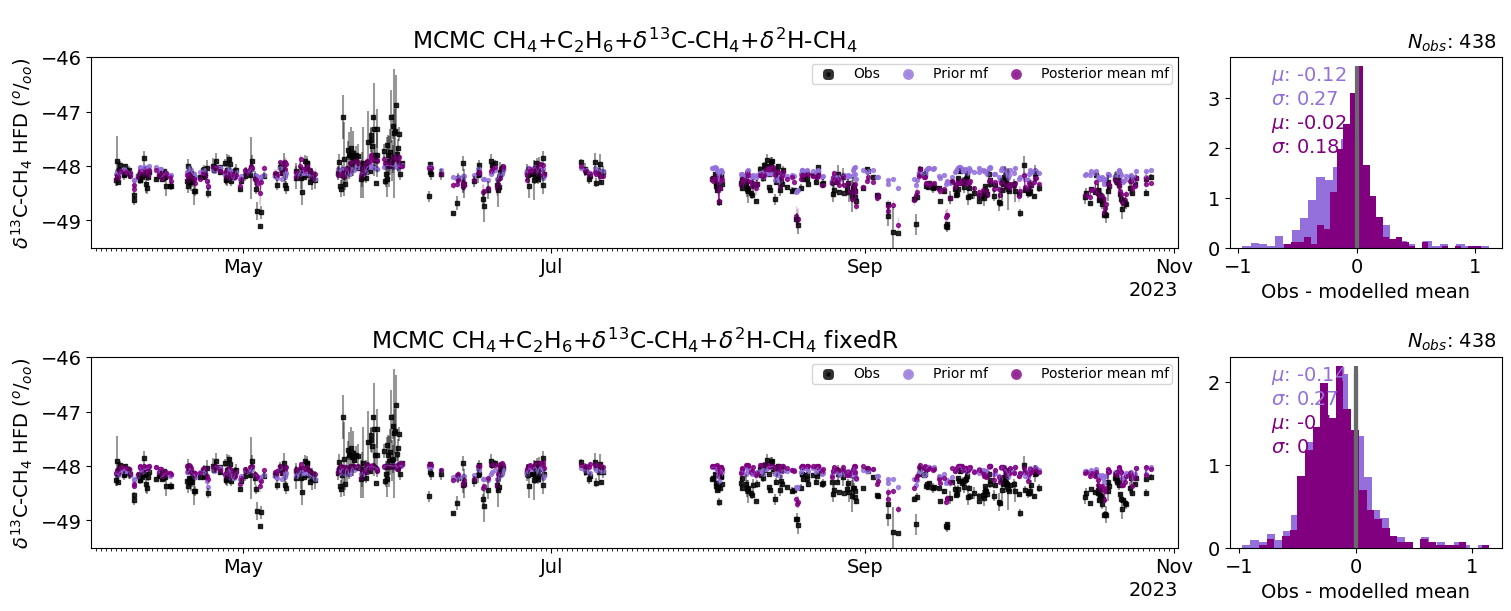

In [18]:
fig = func.plot_obs_modelled_separate(ds_all_mf_sliced,plot_species,site,model_labels,
                                      model_colors,
                             include=['Yobs','Yapriori','Yapost'],
                             diff_include=['Yapriori','Yapost'],line_plot_with_scatter=False,y_lim=[-49.5,-46])#)#y_lim=[-108,-80]) #

###################################

### Instructions for timeseries plotting: 
# - Add variables that you want to plot in "include"
# - To plot the histogram of the variables in "include", leave "diff_include" empty
# - To plot the histogram of Obs-variable, add the desired variable to be subtracted in "diff_include" (default value of "diff_include" = Yapost)
# - To erase uncertainty bars around the mean values of Yobs and Yapost set "add_unc" to False (default value of "add_unc" = True)
###################################

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/real_data_results/post_dch4d_HFD_all_models_gaussian_2uncert_202202-202206.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

In [ ]:
o = xr.open_dataset('/home/h02/aramsden/results/multi_gas_MCMC/MCMC_output/real_data/ch4_c2h6/real-varR_ch4_c2h6_20230201-150basis_7sites_EUROPE_01uncertBC_post.nc')
o_old = xr.open_dataset('/home/h02/aramsden/results/multi_gas_MCMC/MCMC_output/real_data/ch4_c2h6/real-varR_ch4_c2h6_20230201-150basis_7sites_EUROPE_full_run_post.nc')


In [ ]:
plt.plot(o['ybc_post_std_c2h6'])
plt.plot(o_old['ybc_post_std_c2h6'])


#### Correlation between mf or bc and post fluxes?

In [ ]:
ym = ['2022-01-01','2022-02-01','2022-03-01','2022-04-01','2022-05-01','2022-06-01','2022-07-01',
      '2022-08-01','2022-09-01','2022-10-01','2022-11-01','2022-12-01',
      '2023-01-01','2023-02-01','2023-03-01','2023-04-01','2023-05-01','2023-06-01','2023-07-01',
      '2023-08-01','2023-09-01','2023-10-01']
post_mf = []
model = 'mcmc_c2h6_d13_dD'
model = 'mcmc_c2h6'
for i in ym:
    t_index = np.logical_and(ds_all_mf_sliced[model]['time_c2h6'].values >= np.datetime64(i),
                             ds_all_mf_sliced[model]['time_c2h6'].values < (np.datetime64(i)+np.timedelta64(30,'D')))
    c2h6_base = np.nanpercentile(ds_all_mf_sliced[model]['Yapost_c2h6'].values[t_index],25)
    post_mf.append(np.nanmean(ds_all_mf_sliced[model]['YapostBC_c2h6'].values[t_index]-c2h6_base))
    #post_mf.append(np.nanmean(ds_all_mf_sliced[model]['YapostBC_c2h6'].values[t_index]))

In [ ]:
c_index = np.where(ds_all_flux_scaled[model]['countrynumber'].values == 'GBR')[0][0]
ff_flux = ds_all_flux_scaled[model]['country_flux_FF_posterior'][:,c_index].values

post_mf = np.array(post_mf)

post_mf_finite = np.isfinite(post_mf)
post_mf_no_nans = post_mf[post_mf_finite]
ff_flux_no_nans = ff_flux[post_mf_finite]

ff_flux_finite = np.isfinite(ff_flux_no_nans)
post_mf_no_nans = post_mf_no_nans[ff_flux_finite]
ff_flux_no_nans = ff_flux_no_nans[ff_flux_finite]

from code.plotting import generic_plots

fig = generic_plots.scatter_plot_with_basic_linear_regression(a=np.expand_dims(ff_flux_no_nans,axis=1),
                                                          b=np.expand_dims(post_mf_no_nans,axis=1),
                                                          a_label=f'{model_labels["mcmc_c2h6_d13_dD"]}\nposterior mean FF flux',
                                                          #b_label=f'Mean of monthly C$_2$H$_6$ posterior bc - approx obs baseline')
                                                          b_label=f'Mean of monthly C$_2$H$_6$ posterior mf')
                                                          

#generic_plots.savefig(fig,'/home/h02/aramsden/results/multi_gas_MCMC/real_data_results/scatter_post_c2h6_mf_vs_FF_flux.png')

In [ ]:
plt.plot(post_mf)

#### Timeseries plot, all models together:

In [ ]:
fig = func.plot_obs_modelled_together(ds_all_mf_sliced,plot_species,site,model_labels,
                                      model_colors,
                             include=['Yobs','Yapost'],
                             diff_include=['Yapost'],add_unc=True,
                             y_lim=None,line_plot_with_scatter=True)

#### Absolute differences between two models:

In [ ]:
fig = func.plot_obs_diff(ds_all_mf_sliced,plot_species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'])

#### Calculate and plot stats for the fit to obs:

In [ ]:
ds_all_allsites = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=plot_species)

pearson,nrmse = func.stats_mf(ds_all_allsites,species)

fig = func.plot_stats_mf(pearson,nrmse,species,model_labels,
                         model_colors,
                  start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/ch4/total_flux_results/fit_to_obs_ch4_icos_sites'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:

In [ ]:
###################################
### edit variables in this block
species = 'ch4'
start_date = '2023-04-01' #select the time period to plot (a month or year, depending on the inversion period)
end_date = '2023-11-01' #if end_date doesn't = start_date, a mean average of the whole period will be plotted
#models = ['mcmc','mcmc_d13_fixedR','mcmc_d13_varR']
#models = ['mcmc_gaussian_2uncert','mcmc_c2h6_gaussian_2uncert','mcmc_d13_dD_gaussian_2uncert','mcmc_c2h6_d13_dD_gaussian_2uncert']
models = ['mcmc_gaussian_2uncert','mcmc_c2h6_gaussian_2uncert','mcmc_c2h6_fixedR','mcmc_c2h6_d13_dD_gaussian_2uncert','mcmc_c2h6_d13_dD_fixedR']
#sectors = [['FF','nonFF'],['FF','nonFF'],['FF','nonFF'],['FF','nonFF']] # list of list of sector names, for each model
#sectors = [['FF','nonFF'],['FF','nonFF'],['FF','nonFF'],['FF','nonFF']] # list of list of sector names, for each model
sectors = [['nonFF'],['nonFF'],['nonFF'],['nonFF']] # list of list of sector names, for each model

period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:

    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                    species=species)[m]

##### Prior and posterior fluxes for all models:

In [ ]:
###################################
### edit variables in this block
plot_area = 'UK' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'viridis'   #Greens
cmap_diff = 'bwr' #'coolwarm'
c_border = 'floralwhite'    #country boundary colour
plot_site_locations = True #If True, adds markers to plots at locations of obs sites 
plot_point_markers = None #['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
plot_scaling_factors = True
################################### 

fig = func.plot_spatial_flux(ds_all_flux_scaled,species,plot_area,model_labels,
                             cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                             period_override=period_override,plot_site_locations=plot_site_locations,
                             plot_point_markers=plot_point_markers,
                             season=None,sectors=sectors,plot_scaling_factors=plot_scaling_factors)

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/real_data_results/post_202304-202310_spatial_fluxes_all_models_nonFF.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Directly compare posterior fluxes from two models:

In [ ]:
fig = func.plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,model_labels,
                                        cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                        period_override=period_override,
                                        plot_site_locations=plot_site_locations,
                                        plot_point_markers=plot_point_markers,
                                        sectors=sectors)

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/ch4/total_flux_results/spatial_flux_total_ch4_icos_sites_202308_intem_diff'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Directly compare posterior fluxes from two models with multiple sectors:

In [ ]:
###################################
### edit variables in this block
plot_area = 'NWEU' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'viridis'   #Greens
cmap_diff = 'bwr'   #coolwarm
c_border = 'floralwhite'    #country boundary colour
plot_site_locations = False #If True, adds markers to plots at locations of obs sites 
plot_point_markers = None #['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
###################################

fig = func.plot_spatial_flux_comparison_sectors(ds_all_flux_scaled,species,plot_area,model_labels,
                                        cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                        period_override=period_override,
                                        plot_site_locations=plot_site_locations,
                                        plot_point_markers=plot_point_markers,
                                        sectors=sectors)

In [ ]:
output_path = '/home/h02/aramsden/results/multi_gas_MCMC/real_data_results/post_202304-202310_sector_spatial_fluxes_ch4-only_ch4-c2h6.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Plot spatial flux per timestamp - needs editing to work with multi sector

In [ ]:
###################################
### edit variables in this block
plot_area = 'CWEU'   #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'coolwarm'    #flux colour (e.g. 'viridis', 'coolwarm')
c_border = 'dimgrey' #country boundary colour (e.g. 'floralwhite', 'dimgrey')
chop_by = 'year'     #time unit of the averaging period (options for 'year', 'month' and 'season')
                     #alternatively, a list of starting dates can be provided (format '2018-01-01')
dt = 2               #number of time steps (in chop_by units) to use in the averaging
                     #if chop_by='season': set dt to a list of lists with the months to use in the average (e.g. dt=[[1,2],[10,11]], will average over Jan-Feb and Oct-Nov)
var = 'posterior_prior_diff'  #variable to be plotted.
                              #options for: 'flux_total_posterior', 'flux_total_prior', 'posterior_prior_diff'
plot_site_locations = True #If True, adds markers to plots at locations of obs sites
plot_point_markers = ['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
###################################

fig = func.plot_spatial_flux_per_timestamp(ds_all_flux_scaled,species,plot_area,model_labels,end_date,
                                            cmap=cmap,c_border=c_border,
                                            var=var,chop_by=chop_by,dt=dt,period_override=period_override,
                                            plot_site_locations=plot_site_locations,
                                            plot_point_markers=plot_point_markers)

### 7. Compare region definitions

THIS NEEDS UPDATING TO COMPARE MULTIPLE MODELS - CURRENTLY THESE NEED TO BE INPUT MANUALLY

In [ ]:
species = 'ch4' #select the species you want to plot
plot_region = 'UK' #choose the region mask to plot

In [ ]:
# Read in emissions output

intem = xr.open_dataset(os.path.join(data_dir,f'InTEM_NAME_EUROPE_{intem_species[species]}_{period[m][species]}.nc'))
#rhime = xr.open_dataset(os.path.join(data_dir,f'RHIME_NAME_EUROPE_{species}_{period}.nc'))
#empa = xr.open_dataset(os.path.join(data_dir,f'{empa_name}_FLEXPART_EUROPE_{species}_{period}.nc')) 

try:
    intem_r0 = np.where(intem['countrynames'].values == plot_region)[0][0]
except:
    print(f'No region in InTEM called {plot_region}')

In [ ]:
ax_limits = [-12,25,40,65] #min_lon, max_lon, min_lat, max_lat

fig,ax = plt.subplots(2,3,figsize=(12,6),constrained_layout=True,
                          subplot_kw={'projection':cartopy.crs.PlateCarree()})

for i in range(2):
    for j in range(3):
        ax[i,j].add_feature(cartopy.feature.BORDERS,linestyle=':',edgecolor='black',linewidth=1.)
        ax[i,j].coastlines(resolution='50m',color='black',linewidth=1.)
        ax[i,j].set_extent(ax_limits)
        
#plot intem
ax[0,0].pcolormesh(intem.lon.values,intem.lat.values,intem['region_definitions'][:,:,intem_r0],cmap='Blues',
                 vmin=0,vmax=2)
ax[0,0].set_title(f'InTEM {plot_region} mask')

#plot difference
#ax[1,0].pcolormesh(intem.lon.values,intem.lat.values,
#                   intem['region_definitions'][:,:,intem_r0]-rhime['region_definitions'][:,:,rhime_r0],
#                   cmap='bwr')
ax[1,0].set_title(f'InTEM {plot_region} - RHIME {plot_region}')